# EDA — [Spotify Tracks Dataset]

In [29]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("../data/processed/clean_tracks.csv")
df.describe()
df.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217


### Question 1 : How is popularity distributed?

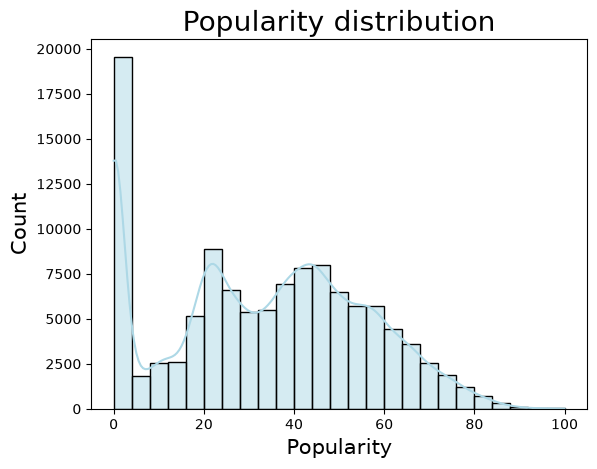

In [ ]:
sns.histplot(df["popularity"], bins= 25, kde=True, color= "lightblue")
plt.title("Popularity distribution", fontsize = 20)
plt.xlabel("Popularity" , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/popularity_dist.png", dpi=300)

 # Insights >
 - most of the  tracks cluster around popularity  0 - 60few hits above 80 
 - the curve is non symetric 

### Question 2 : How is tempo is  distributed? 
-  here tempo is Speed of the song in beats per minute (BPM) 
- E.X Slow = 70 BPM, Dance = 120–140 BPM.

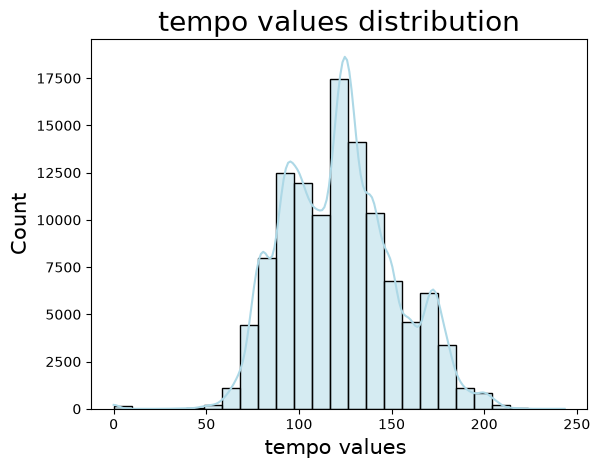

In [22]:
sns.histplot(df["tempo"], bins= 25, kde=True, color= "lightblue")
plt.title("tempo values distribution", fontsize = 20)
plt.xlabel("tempo values " , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/tempo_dist.png", dpi=300)

 # Insights >
 - Tempo peaks around 120–130 BPM, consistent with dance-genre tracks dominating the dataset
 - There is a potential outlier near 0 BPM, which may represent missing or erroneous data 

### Question 3 : How is Danceability is  distributed? 


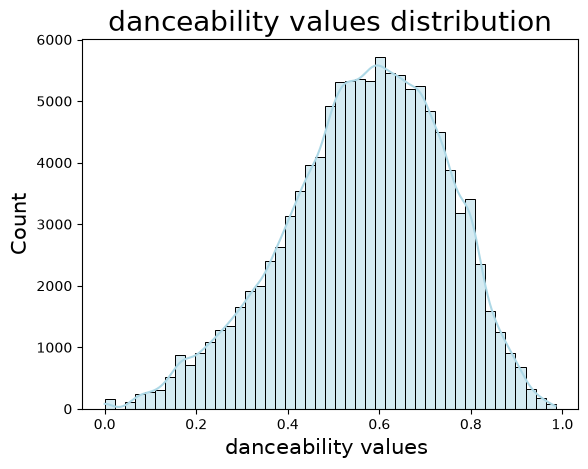

In [ ]:
sns.histplot(df["danceability"], bins= 45, kde=True, color= "lightblue")
plt.title("danceability values distribution", fontsize = 20)
plt.xlabel("danceability values " , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/danceability_dis.png", dpi=300)

 # Insights >
 - Danceability is concentrated between 0.4 and 0.8, with a peak around 0.6, suggesting that most tracks are moderately to highly danceable
 

### Question 4 : How is energy levels are  distributed? 
- here [energy: is the perceived power, emotional intensity, and physical momentum of a song or performance]

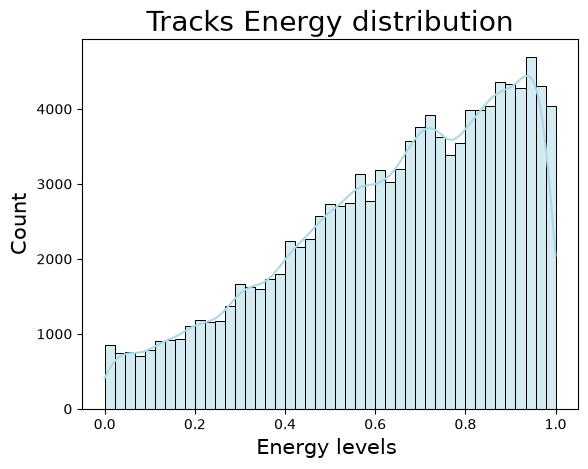

In [15]:
sns.histplot(df["energy"], bins= 45, kde=True, color= "lightblue")
plt.title("Tracks Energy distribution" , fontsize = 20)
plt.xlabel(" Energy levels  " , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/Energy.png", dpi=300)

# Insgihts >
- Energy values are left-skewed, with most tracks having high energy
- Most songs have energy between 0.7 and 1.0
- Very few tracks have low energy (< 0.3)

### Question 5:  How are explicit and non-explicit songs distributed in the dataset?
- here [(Explicit content) refers to songs containing strong language ]

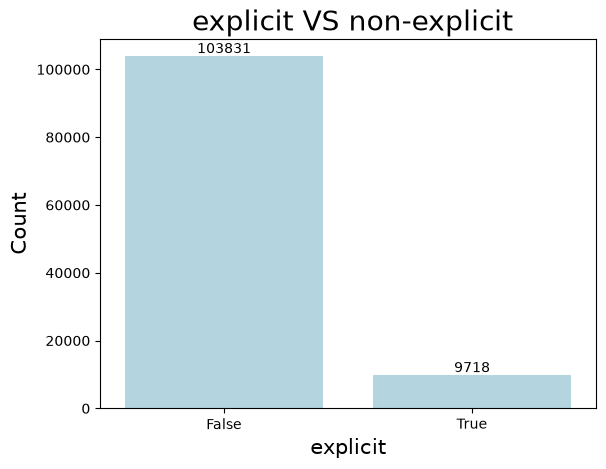

In [36]:
expl_count = df["explicit"].value_counts()
ax= sns.barplot(expl_count , color= "lightblue")
ax.bar_label(ax.containers[0])
plt.title(" explicit VS non-explicit", fontsize = 20)
plt.xlabel("explicit" , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/explicity.png", dpi=300)

 # Insights >
 - The dataset is heavily dominated by non-explicit songs
 - Approximately 91% of the songs are non-explicit, while only about 9% are explicit


### Question 6:  How are songs distributed between major and minor musical keys?
- here >
- A song in a major key can sound emotional or melancholic.
- A song in a minor key can sound energetic or uplifting

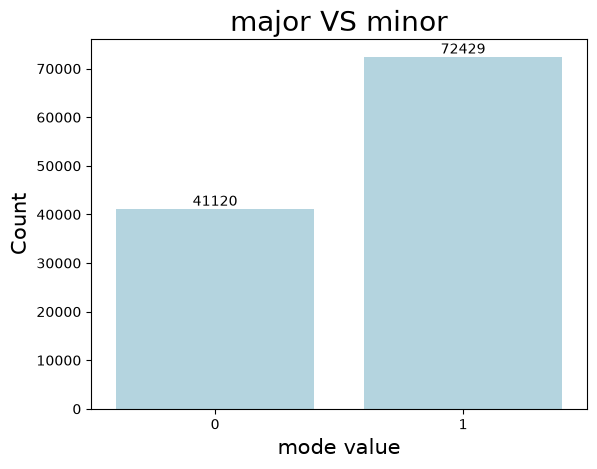

In [128]:
mode_count = df["mode"].value_counts()
ax= sns.barplot(mode_count , color= "lightblue")
ax.bar_label(ax.containers[0])
plt.title(" major VS minor ", fontsize = 20)
plt.xlabel("mode value" , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/Mode.png", dpi=300)


# Insights >
- The dataset contains more songs in the major key than in the minor key
- Major-key[1] songs account for approximately 64% of the dataset, while minor-key[0] songs make up about 36%

### Question 7: Which time signature is the most common among the tracks? ?
- here [time_signature] Number of beats per measure

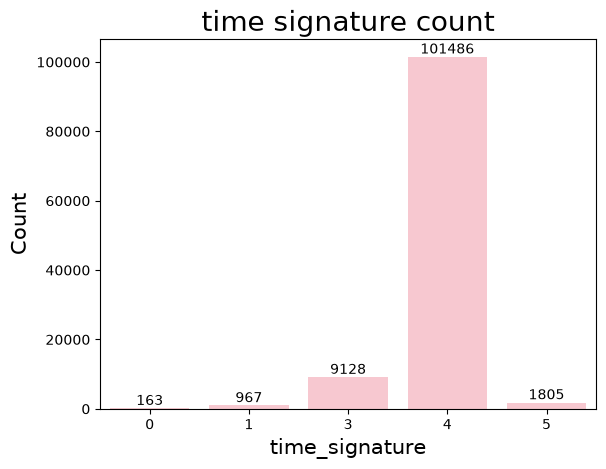

In [79]:
time_sig_count = df["time_signature"].value_counts()
tim_sig_perc= (df["time_signature"].value_counts(normalize=True) * 100).round(2)
ax = sns.barplot(time_sig_count , color= "pink" )
ax.bar_label(ax.containers[0])
plt.title("time signature count" , fontsize= 20)
plt.xlabel("time_signature" , fontsize= 15)
plt.ylabel("Count", fontsize = 15)
plt.savefig("../visuals/time_signature.png" , dpi= 300)


# Insights >
- most of the music 89.38% use  a 4/4  time signature 
- Time signatures such as 3/4 (8.04)% and 5/4 (1.59)% are much less common
- A very small number (0.85 ~ 0.14)% of tracks have time signatures of 0 or 1, which may represent missing, unknown

###  Question 8: Which artists have the most tracks in the dataset?

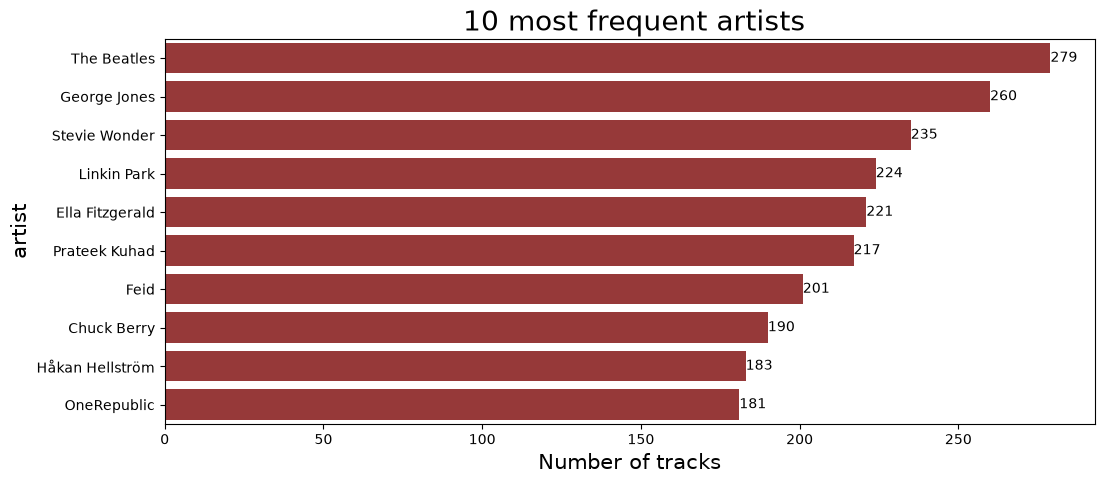

In [129]:
top_artists = df["artists"].value_counts().head(10)
plt.figure(figsize= (12 ,5))
ax= sns.barplot(x= top_artists, y = top_artists.index , color= "brown")
ax.bar_label(ax.containers[0])
plt.title(" 10 most frequent artists" , fontsize= 20)
plt.xlabel("Number of tracks" , fontsize= 15)
plt.ylabel("artist", fontsize = 15)
plt.savefig("../visuals/to 10 artists.png" , dpi= 300)


# Insights >
- The dataset is dominated by a small number of artists, with the top 10 artists contributing the largest number of tracks.
- The mvp  of this data set is artist "the beatles" with highest  279 no. of tracks 
- the 2nd mvp of this set is artis "George jones" with 260 no. of tracks 
-  and linkin park is my fav :)

### Question 9: Which albums contain the most tracks in the dataset?

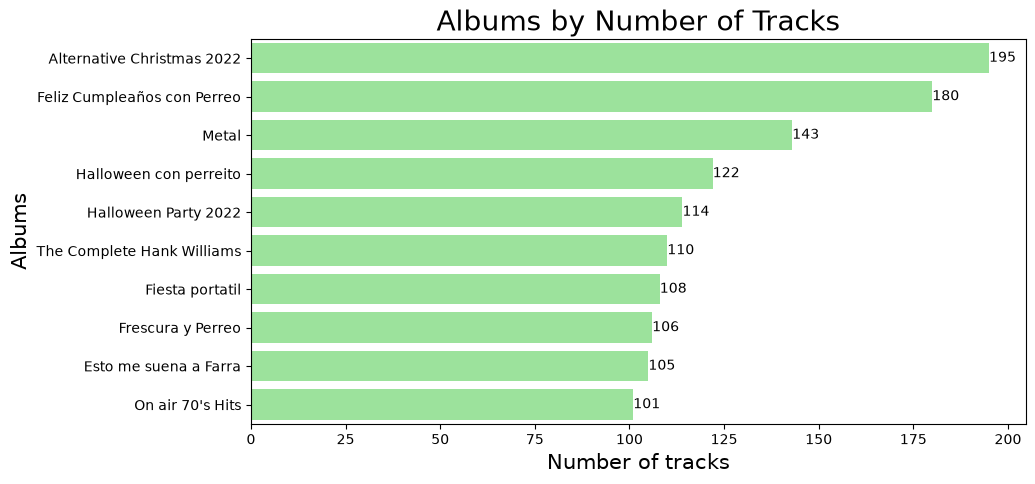

In [21]:
top_albums = df["album_name"].value_counts().head(10)
plt.figure(figsize=(10 , 5))
ax= sns.barplot(x= top_albums , y = top_albums.index , color="lightgreen" )
ax.bar_label(ax.containers[0])
plt.title("Albums by Number of Tracks", fontsize= 20)
plt.xlabel("Number of tracks" , fontsize= 15)
plt.ylabel("Albums", fontsize = 15)
plt.savefig("../visuals/top albums.png" , dpi= 300)


# Insights>
- "Alternative Christmas 2022" contains the highest number of tracks (195) in the dataset
- the top 10 albums each contain more than 100 tracks, indicating that these albums are well represented in the dataset
- the difference in track counts between the top-ranked albums is relatively small means fairly balanced distribution

### Question 10: How are tracks distributed across different genres?

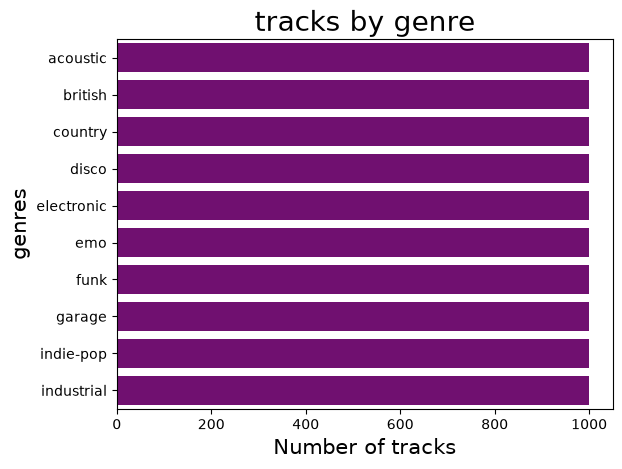

In [20]:
top_genre = df["track_genre"].value_counts().head(10)

sns.barplot(x= top_genre , y= top_genre.index , color= "purple")
plt.title("tracks by genre", fontsize= 20)
plt.xlabel("Number of tracks" , fontsize= 15)
plt.ylabel("genres", fontsize = 15)
plt.savefig("../visuals/top genre.png" , dpi= 300)

# Insights >
- The dataset is balanced, with each genre containing approximately 1,000 tracks
- This balanced distribution is suitable for training and evaluating genre classification models

### Question 11: Which numerical features are strongly correlated with each other, and are there any features that show a relationship with track popularity?
- here 
- |r| ≥ 0.70 → Strong
- 0.30 ≤ |r| < 0.70 → Moderate
- |r| < 0.30 → Weak

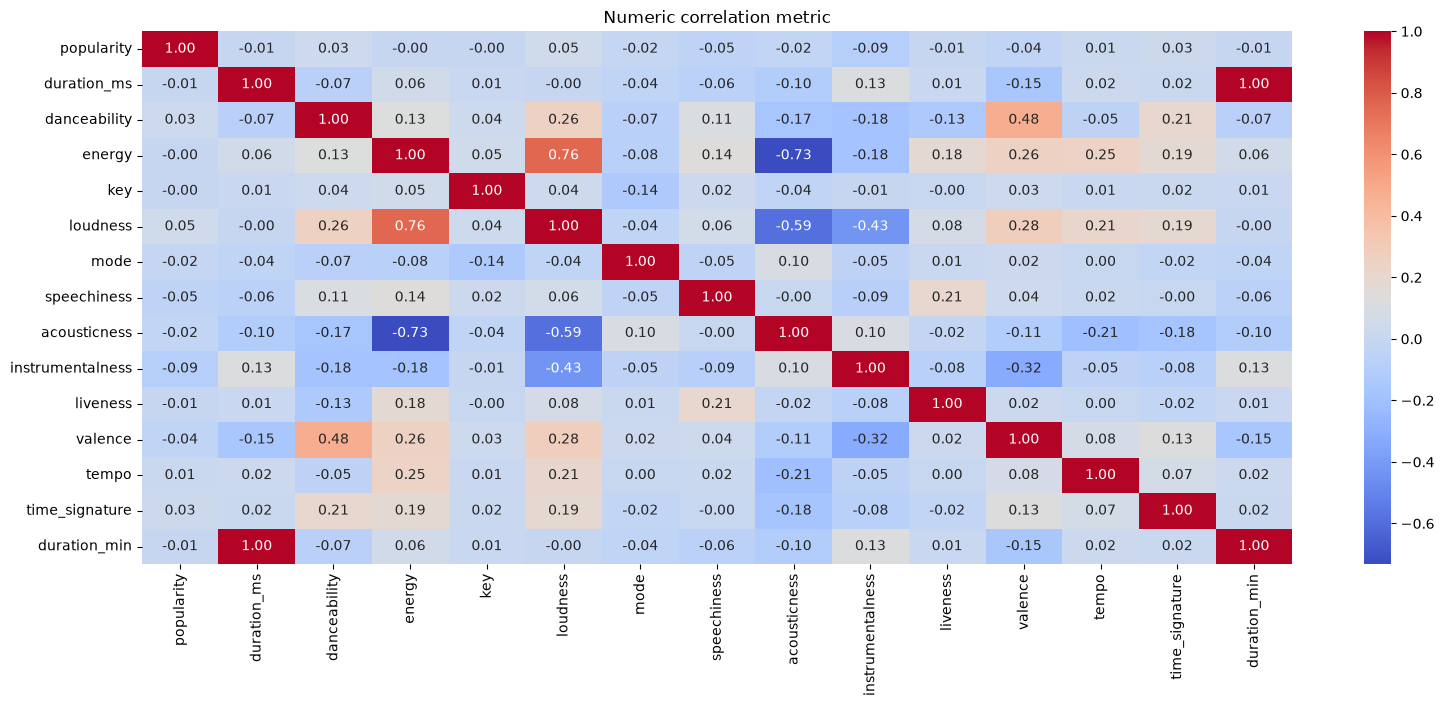

In [6]:
# corree
numeric_val = df.select_dtypes(include= "number")
corre_mat = numeric_val.corr()

plt.figure(figsize= (16 ,7))
sns.heatmap(
    corre_mat,
    annot= True,
    fmt= ".2f",
    cmap= "coolwarm"
)
plt.tight_layout()
plt.title(" Numeric correlation metric ")
plt.savefig("../visuals/top correlation.png" , dpi= 300)

# Insights >
- popularity has very weak correlations with all audio features (|r| < 0.10), 
  suggesting that no single feature strongly determines a track's popularity
- Energy and loudness have a strong positive correlation (r = 0.76), indicating that more energetic songs tend to be louder
- Energy and acousticness show a strong negative correlation (r = -0.73), meaning highly energetic songs are generally less acoustic
- Danceability and valence have a moderate positive correlation (r = 0.48), suggesting happier songs are often more danceable
- Loudness and acousticness have a moderate negative correlation (r = -0.59), indicating acoustic tracks are typically quieter.

### Question 12: How do audio characteristics vary among the most popular music genres

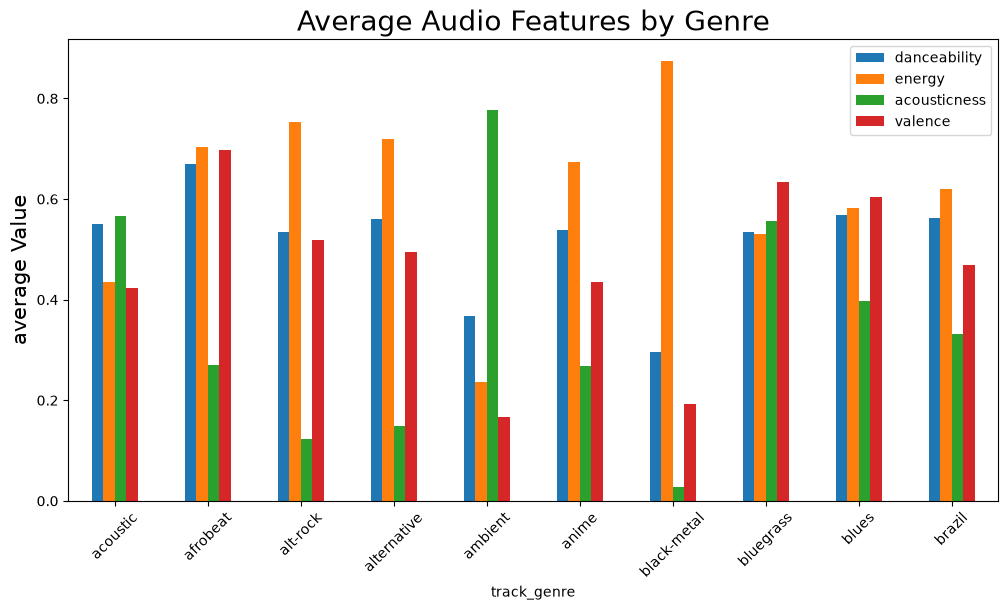

In [34]:
aud_features = ["danceability", "energy","acousticness", "valence" , ]

genre_avg = (
        df.groupby("track_genre")[aud_features]
        .mean()
        .head(10) # top 10 genres
)

genre_avg.plot(kind= "bar", figsize=(12,6))

plt.title("Average Audio Features by Genre" , fontsize= 20)
plt.ylabel("average Value", fontsize= 15)
plt.xticks(rotation=45)
plt.savefig("../visuals/ avg_audio feature by genre.png" , dpi = 300 )
plt.show()

# Insights>
- Different genres show distinct average audio feature values
- Some genres are more energetic[black-metal], while others are more acoustic[ambient]
- Danceability and valence vary noticeably between genres, reflecting different musical styles 


### Question 13: How do the average audio characteristics differ across music genres?

In [42]:
features = ["danceability" , "energy", "acousticness", "valence", "speechiness"]

genre_avg = (
    df.groupby("track_genre")[features]
    .mean()
    .loc[["pop", "black-metal", "jazz" ]]

)

genre_avg

,danceability,energy,acousticness,valence,speechiness
track_genre,,,,,
pop,0.630408,0.605502,0.345772,0.506931,0.080174
black-metal,0.296670,0.874721,0.027137,0.192131,0.087169
jazz,0.509892,0.353205,0.715545,0.490336,0.054987


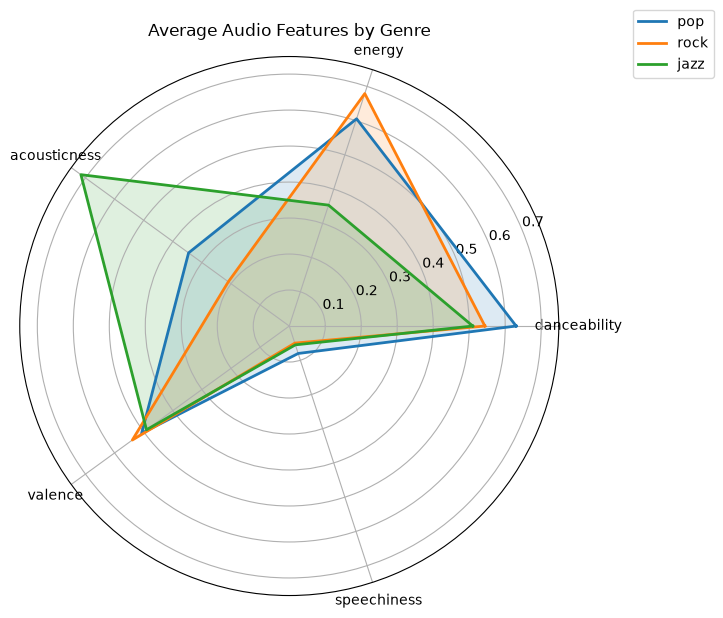

In [41]:
#  Spider chart >

import numpy as np 

labels = genre_avg.columns
numeric_val = len(labels)

angles = np.linspace(0 , 2*np.pi, numeric_val , endpoint= False ).tolist()
angles += angles[:1]  # circle end 

fig , ax = plt.subplots(figsize = (7,7), subplot_kw = dict(polar = True))


for genre in genre_avg.index:
    values = genre_avg.loc[genre].tolist()
    values += values[:1]    

    ax.plot(angles , values , linewidth = 2  , label= genre)
    ax.fill(angles , values , alpha = 0.15 )

ax.set_xticks(angles[:-1])   
ax.set_xticklabels(labels) 


plt.title("Average Audio Features by Genre")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.savefig("../visuals/ spider_chart avg_audioby genre.png"  )


# Insights>
- Pop songs are generally the most danceable among the selected genres.
- Black-metal is characterized by very high energy and very low acousticness
- Speechiness is low across all three genres, showing that spoken-word content is uncommon.


# Summary :)

- Most tracks have **low to moderate popularity (0–60)**, with relatively few highly popular tracks scoring above 80
- The dataset is dominated by **high-energy songs**, as the energy distribution is left-skewed toward higher values
- Approximately 91% of the songs are non-explicit, while only about 9% are explicit
- The dataset is **well balanced across genres**, with each genre containing approximately **1,000 tracks**, making it suitable for   genre-based  analysis and machine learning tasks
- Strong relationships were observed among audio features, particularly between **energy and loudness (positive)** and **energy and acousticness (negative)**
- Overall]: the dataset is clean, balanced, and rich in audio features, making it well suited for further statistical analysis, visualization, and predictive modeling.